In [1]:
# let's characterize all of the detectors with *working* amp circuits

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [3]:
unoDF = pd.read_csv('./noMagUNO3.CSV')
dosDF = pd.read_csv('./noMagDOS4.CSV')
tresDF = pd.read_csv('./noMagTRES8.CSV')

In [4]:
voltCon = 5/16383
sampFreq = 100
nper = 300
unoDF['sensor'] = pd.to_numeric(unoDF['sensor'], errors='coerce')
dosDF['sensor'] = pd.to_numeric(dosDF['sensor'], errors='coerce')
tresDF['sensor'] = pd.to_numeric(tresDF['sensor'], errors='coerce')

unoDF = unoDF.dropna(subset=['sensor']).reset_index(drop=True)
dosDF = dosDF.dropna(subset=['sensor']).reset_index(drop=True)
tresDF = tresDF.dropna(subset=['sensor']).reset_index(drop=True)

unoVolt = unoDF['sensor'].to_numpy(dtype=float) * voltCon
dosVolt = dosDF['sensor'].to_numpy(dtype=float) * voltCon
tresVolt = tresDF['sensor'].to_numpy(dtype=float) * voltCon

In [5]:
'''unoVolt = np.array(unoDF['sensor']*voltCon)
dosVolt = np.array(dosDF['sensor']*voltCon)
tresVolt = np.array(tresDF['sensor']*voltCon)

unoVolt = unoDF['sensor'].to_numpy(dtype=float) * voltCon
dosVolt = dosDF['sensor'].to_numpy(dtype=float) * voltCon
tresVolt = tresDF['sensor'].to_numpy(dtype=float) * voltCon'''

"unoVolt = np.array(unoDF['sensor']*voltCon)\ndosVolt = np.array(dosDF['sensor']*voltCon)\ntresVolt = np.array(tresDF['sensor']*voltCon)\n\nunoVolt = unoDF['sensor'].to_numpy(dtype=float) * voltCon\ndosVolt = dosDF['sensor'].to_numpy(dtype=float) * voltCon\ntresVolt = tresDF['sensor'].to_numpy(dtype=float) * voltCon"

In [6]:
step = 50  # keep every 50th point
plt.plot(unoDF['seconds'][::step], unoVolt[::step])

#plt.plot(unoDF['seconds'],unoVolt,label='uno')
#plt.plot(dosDF['seconds'],dosVolt,label='dos')
#plt.plot(tresDF['seconds'],tresVolt,label='tres')
plt.xlabel('seconds')
plt.ylabel('volts')
plt.semilogy()
plt.legend()
plt.show()

Locator attempting to generate 359044 ticks ([-3264.0, ..., 68544.6]), which exceeds Locator.MAXTICKS (1000).


MemoryError: Unable to allocate 99.5 GiB for an array with shape (359044, 37179) and data type float64

<Figure size 640x480 with 1 Axes>

In [7]:
unoFGrid,unoPSD = sp.signal.welch(unoVolt,fs=sampFreq,nperseg=nper)
dosFGrid,dosPSD = sp.signal.welch(dosVolt,fs=sampFreq,nperseg=nper)
tresFGrid,tresPSD = sp.signal.welch(tresVolt,fs=sampFreq,nperseg=nper)

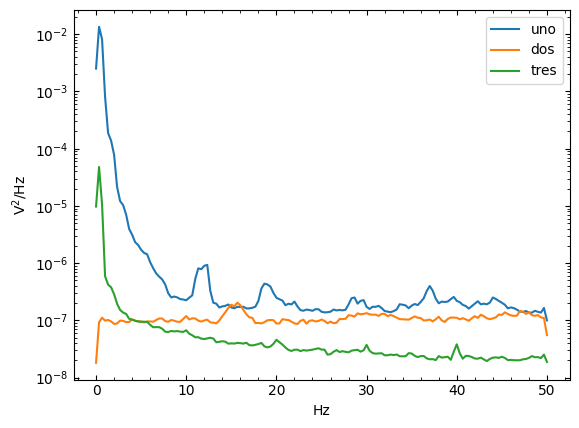

In [8]:
plt.plot(unoFGrid,unoPSD,label='uno')
plt.plot(dosFGrid,dosPSD,label='dos')
plt.plot(tresFGrid,tresPSD,label='tres')
plt.xlabel('Hz')
plt.ylabel('V$^2$/Hz')
plt.semilogy()
plt.legend()
plt.show()

In [9]:
print(type(voltCon))
print(voltCon)


<class 'float'>
0.0003051944088384301
